[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Harvard-CS1090/2026-CS1090A-public/blob/sec05-2026/sec05/cs1090a_sec05_student.ipynb)

> **On Colab, do `File → Save a copy in Drive` before you start.** This notebook opens from GitHub, so you can type in it and run it right away — but nothing is being saved anywhere. Close the tab and the work is gone. Saving a copy first gives you one that persists in your own Drive.

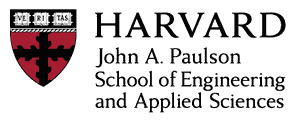

# CS1090A Introduction to Data Science

### Section 5 — Regression coefficients, bootstrap uncertainty, and regularization

<div style="background:#E8F1FF; border-left:6px solid #2563EB; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🎯 Objectives</div>
<ul>
<li>Interpret regression coefficients as conditional associations and distinguish them from marginal correlations.</li>
<li>Use the bootstrap to compare coefficient size, uncertainty, normalized importance, and 95% intervals.</li>
<li>Compare polynomial OLS, ridge, and lasso; tune alpha with training-fold CV and assess performance on held-out validation rows.</li>
</ul>
</div>

**Section flow:** Part 1 fits an OLS model with ten predictors, Part 2 uses the bootstrap to measure how uncertain its coefficients are, and Part 3 fits polynomial regression with ridge and lasso. Green boxes are exercises; red boxes are discussions with worked answers for TFs.

**The data.** 442 diabetes patients were measured once at the start of a study: age, sex,
body mass index, blood pressure, and six blood-serum measurements. One year later, each
patient's disease progression was scored. The data ships with scikit-learn, so it loads
without a network connection. The data is from [this paper](https://projecteuclid.org/journalArticle/Download?urlId=10.1214%2F009053604000000067). The target $y$ is disease progression (higher values are worse).

## Part 1. The ten-predictor model

### Load the data

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.linear_model import ElasticNetCV, Lasso, LassoCV, Ridge, RidgeCV

sns.set_theme(style="whitegrid", context="notebook")

In [ ]:
# scaled=False keeps the original units. The default, scaled=True, returns every column
# already centred and rescaled; here we fit the scaler on each fitting sample.
diabetes = load_diabetes(scaled=False, as_frame=True)
df = diabetes.frame
df.head(3)

| Column | What it records | Units, as loaded |
|---|---|---|
| `age` | age | years |
| `sex` | sex, coded as 1 or 2 | a category stored as a number |
| `bmi` | body mass index | kg/m² |
| `bp` | average blood pressure | mm Hg |
| `s1` | total serum cholesterol | mg/dL |
| `s2` | low-density lipoproteins (LDL cholesterol) | mg/dL |
| `s3` | high-density lipoproteins (HDL cholesterol) | mg/dL |
| `s4` | total cholesterol divided by HDL | a ratio |
| `s5` | log of serum triglycerides | log(mg/dL) |
| `s6` | blood sugar | mg/dL |
| `target` | disease progression one year after these measurements | points on a clinical scale |

### Separate X and y

In [ ]:
predictors = list(diabetes.feature_names)
X = diabetes.data.copy()
y = diabetes.target.copy()
X.shape, y.shape

In [ ]:
# convert sex from {1, 2} to {0, 1}
X['sex'] = 1*(diabetes.data.sex == 2)

We begin with all ten predictors. In Part 2, we compare this full model with a model that omits four serum predictors.

In [ ]:
FULL = ["age", "sex", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6"]

### Train / Validation / Test Split

In [ ]:
# X_dev pools training + validation rows; the test split stays untouched in the main section.
# Performance comparisons fit on X_train and score on X_val. Bootstrap uncertainty uses X_dev.
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.2, random_state=1090)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.25, random_state=2090)
print(f"train {len(X_train)}    val {len(X_val)}    test {len(X_test)}")

### Pipeline

Scale each predictor using the fitting sample’s mean and standard deviation, then fit OLS. The pipeline applies that same fitted transformation to validation rows; the outcome remains in its original units.

In [ ]:
def make_preprocessor():
    pipe = make_pipeline(StandardScaler())
    pipe.set_output(transform="pandas")
    return pipe
def make_model(estimator):
    "This will work for any kind of model (we'll need it later...)"
    return Pipeline([
        ("preprocess", make_preprocessor()),
        ("model", estimator),
    ])

In [ ]:
def standardized_ols():
    # Standardize every column (fitted on the rows passed to .fit), then least squares
    return make_model(LinearRegression())

In [ ]:
pipe = standardized_ols().fit(X_train, y_train)

In [ ]:
def coefficients(fitted_pipeline, names=None):
    # The last step's coefficients, labelled by column name
    return pd.Series(fitted_pipeline[-1].coef_, index=predictors if names is None else names)

In [ ]:
ols_coefs_full = coefficients(pipe, FULL)
ols_coefs_full.round(1)

In [ ]:
# The original ten-predictor model on the fixed training/validation split.
ols_train_r2 = r2_score(y_train, pipe.predict(X_train))
ols_val_r2 = r2_score(y_val, pipe.predict(X_val))
print(f"Original OLS: train R² = {ols_train_r2:.3f}; validation R² = {ols_val_r2:.3f}")

This split shows no clear training–validation gap for the ten-predictor model. That is not proof that the model can never overfit.

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 1: interpreting the surprising sign</div>
<ol>
<li>What does the negative <code>s1</code> coefficient say about disease progression, holding the other predictors fixed?</li>
<li>Why might this surprise us? Does it show that total cholesterol is protective?</li>
</ol>
</div>

Compare this with each predictor’s marginal correlation with disease progression, using the same training rows.

In [ ]:
# Each predictor's correlation with the target, one column at a time
X_train[FULL].corrwith(y_train).sort_values()

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 2: coefficients versus correlations</div>
<ol>
<li>How does a predictor–outcome correlation differ from a regression coefficient?</li>
<li>Why can <code>s1</code> have a positive correlation but a negative coefficient?</li>
</ol>
</div>

## Part 2. The bootstrap

How precisely do we know our regression coefficients? Our estimates come from one sample of patients and would change if we collected a different sample. If a coefficient changes substantially across samples, we have more uncertainty about its value; if it changes little, we can estimate it more precisely. If we could repeat the study many times, collecting a new sample from the same population and fitting the same model each time, the distribution of the estimated coefficients would show this uncertainty. This is the idea we saw in class.

Repeating the study with new groups of patients is not practical. The **bootstrap** imitates this process using the data we already have: draw a resample of the same size by sampling the rows supplied to the function **with replacement**, so some patients appear more than once and others do not appear at all. Refit the model on each resample. Repeating this many times gives a bootstrap distribution for each coefficient, which we use to estimate its uncertainty.

For this uncertainty demonstration, we use `X_dev` (training and validation pooled), rather than the smaller `X_train` used above. These are different fitting samples, so their point coefficients need not match. Part 3 returns to `X_train` for every fit and keeps `X_val` separate for performance comparison.

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 1: write the bootstrap loop (5 min)</div>
<div>
The setup, coefficient summary, and plots are provided. In the function below, fill in the bootstrap loop (5 minutes). For each <code>b</code>:
<ol>
<li>Sample <code>len(X)</code> row indices with replacement using the provided <code>rng</code>.</li>
<li>Create a model with <code>make_model(LinearRegression())</code> and fit it to <code>X.iloc[idx][features]</code> and the paired targets <code>y.iloc[idx]</code>.</li>
<li>Store <code>coefficients(model, features)</code> in <code>boot[b]</code>.</li>
</ol>
Use the same indices for predictors and targets so each patient's measurements stay paired.
</div>
</div>

In [ ]:

def bootstrap_ols(X, y, features, B=3000, seed=12345):
    rng = np.random.default_rng(seed)

    point_model = make_model(LinearRegression())
    point_model.fit(X[features], y)

    point = coefficients(point_model, features)

    boot = np.empty((B, len(features)))
    # your code here
    for b in range(B):
        idx = ...                                  # len(X) row positions, drawn with replacement using rng
    
        model = make_model(LinearRegression())
        model.fit(..., ...)                        # the resampled rows of X[features], and the same rows of y
    
        boot[b] = ...                              # this fit's coefficients

    lo, med, hi = np.quantile(boot, [0.025, 0.50, 0.975], axis=0)

    summary = pd.DataFrame({
        "estimate": point,
        "bootstrap_lo": lo,
        "bootstrap_median": med,
        "bootstrap_hi": hi,
        "interval_width": hi - lo,
        "Pr_bootstrap_positive": (boot > 0).mean(axis=0),
    })

    summary["95pct_interval_excludes_zero"] = (
        (summary["bootstrap_lo"] > 0) |
        (summary["bootstrap_hi"] < 0)
    )

    return summary, boot

full_boot_summary, full_boot = bootstrap_ols(X_dev, y_dev, FULL)


As we saw in class, we first look at the distribution of each estimated coefficient across the bootstrap resamples.

In [ ]:
# Bootstrap distributions of all ten coefficients
n_resamples = full_boot.shape[0]
fig, axes = plt.subplots(5, 2, figsize=(13, 23), constrained_layout=True, sharex=True)
for i, (ax, column) in enumerate(zip(axes.ravel(), FULL)):
    ax.hist(full_boot[:,i], bins=40, edgecolor="white", color="#7E22CE", alpha=0.85)
    ax.axvline(full_boot_summary.loc[column, "estimate"], color="black", linestyle="--", linewidth=2,
               label="fitted once on development rows")
    ax.axvline(0, color="grey", linewidth=1)
    ax.set(title=f"{column}: coefficient across {n_resamples:,} resamples",
           xlabel="Coefficient per SD of predictor", ylabel="number of resamples",
           xlim=(-100, 100))
    ax.legend(loc="upper left", fontsize=9)
plt.show()
outside_view = ((full_boot < -100) | (full_boot > 100)).sum()
if outside_view:
    print(f"Shared x-axis range hides {outside_view} tail estimate(s); all estimates remain in the calculations.")

This table summarizes the bootstrap distribution for each coefficient.

- `estimate`: the coefficient fitted to the original development sample, not the bootstrap mean.
- `bootstrap_lo` and `bootstrap_hi`: the 2.5th and 97.5th percentiles, enclosing the middle 95% of the bootstrap estimates.
- `bootstrap_median`: the median of the bootstrap estimates.
- `interval_width`: the upper bound minus the lower bound. Narrower intervals indicate more precise estimates.
- `Pr_bootstrap_positive`: the fraction of resampled coefficients greater than zero (the share of the histogram to the right of zero). It is not the probability that the true coefficient is positive.
- `95pct_interval_excludes_zero`: True when the entire interval lies above or below zero. If the interval includes zero, the coefficient’s sign is uncertain; this does not establish that the predictor is irrelevant.

In [ ]:
full_boot_summary.round(2)

### 1. Rank by coefficient size

Each predictor is standardized using the fitting sample’s mean and standard deviation (recomputed in each bootstrap resample). Coefficients measure outcome change per SD of a predictor, holding the others fixed; the outcome is unscaled.

Here we use the **bootstrap mean**, rather than the coefficient from the original fit. Rank by its absolute magnitude while showing signs with color.

In [ ]:
bootstrap_ranking = pd.DataFrame({
    "bootstrap_mean": full_boot.mean(axis=0),
    "bootstrap_sd": full_boot.std(axis=0, ddof=1),
}, index=FULL)
mean_order = bootstrap_ranking["bootstrap_mean"].abs().sort_values().index
ranked_means = bootstrap_ranking.loc[mean_order]
from matplotlib.patches import Patch
mean_colors = np.where(ranked_means["bootstrap_mean"] < 0, "#DC2626", "#2563EB")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(ranked_means.index, ranked_means["bootstrap_mean"].abs(), color=mean_colors)
ax.axvline(0, color="grey", linewidth=1)
ax.set(xlabel="Absolute bootstrap mean coefficient per SD of predictor",
       title="Coefficient size: largest magnitude at the top")
ax.legend(handles=[Patch(facecolor="#DC2626", label="negative coefficient"),
                   Patch(facecolor="#2563EB", label="positive coefficient")])
plt.tight_layout()
plt.show()

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 3: size alone</div>
<ol>
<li>Which predictors have the largest bootstrap mean magnitudes? What does this ranking leave out?</li>
</ol>
</div>

### 2. Add uncertainty

Use the same ordering, now adding **±1 bootstrap standard deviation** around each absolute mean. These bars show spread, not 95% intervals. Smaller spread means greater precision. We show the signed-coefficient SD around the absolute mean to compare size with spread. Bars extending below zero are left visible; they are not intervals for absolute coefficients.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(ranked_means.index, ranked_means["bootstrap_mean"].abs(),
        color=mean_colors, alpha=0.75)
ax.errorbar(ranked_means["bootstrap_mean"].abs(), np.arange(len(ranked_means)),
            xerr=ranked_means["bootstrap_sd"], fmt="none", ecolor="black", capsize=3)
ax.axvline(0, color="grey", linewidth=1)
ax.set(xlabel="Absolute bootstrap mean coefficient per SD of predictor",
       title="Absolute bootstrap mean ±1 bootstrap SD (not 95% intervals)")
ax.legend(handles=[Patch(facecolor="#DC2626", label="negative coefficient"),
                   Patch(facecolor="#2563EB", label="positive coefficient")])
plt.tight_layout()
plt.show()

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 4: size versus precision</div>
<ol>
<li>Which size-based conclusions would you trust less once the bootstrap spread is shown?</li>
</ol>
</div>

### 3. Normalized importance

As in class, define $\hat T = \text{bootstrap mean}/\text{bootstrap SD}$: the coefficient’s size relative to its uncertainty. This divides the coefficient by its estimated uncertainty; standardizing the predictors before fitting was a separate step.

We call this **normalized importance** here. It measures signal relative to noise in the conditional association, not proof of predictive importance or a causal effect. Rank by $|\hat T|$, showing the sign with color.

A zero bootstrap SD gives an undefined ratio, displayed as missing.

In [ ]:
bootstrap_ranking["T_hat"] = (
    bootstrap_ranking["bootstrap_mean"] /
    bootstrap_ranking["bootstrap_sd"].replace(0, np.nan)
)
ratio_order = bootstrap_ranking["T_hat"].abs().sort_values(na_position="first").index
ranked_ratios = bootstrap_ranking.loc[ratio_order]
fig, ax = plt.subplots(figsize=(9, 6))
ratio_colors = np.where(ranked_ratios["T_hat"] < 0, "#DC2626", "#2563EB")
ax.barh(ranked_ratios.index, ranked_ratios["T_hat"].abs(), color=ratio_colors)
ax.axvline(0, color="grey", linewidth=1)
ax.set(xlabel="Absolute normalized importance: |bootstrap mean / bootstrap SD|",
       title="Normalized importance: largest absolute ratio at the top")
ax.legend(handles=[Patch(facecolor="#DC2626", label="negative coefficient"),
                   Patch(facecolor="#2563EB", label="positive coefficient")])
plt.tight_layout()
plt.show()
bootstrap_ranking.loc[ratio_order[::-1]].round(2)

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 5: normalized importance</div>
<ol>
<li>Which predictors rank highest by absolute mean/SD, and what changed?</li>
<li>Does a small ratio prove that a predictor is irrelevant?</li>
</ol>
</div>

### Statistical significance

A 95% bootstrap interval entirely above or below zero provides evidence for the sign of the association. Under the bootstrap approximation, we call this statistically significant at the conventional 5% level. An interval that includes zero means the sign is uncertain; it does not prove there is no association.


Solid bars have `95pct_interval_excludes_zero = True`: the entire 95% interval lies above or below zero. Faded bars have intervals including zero. Red and blue indicate negative and positive coefficients independently of this flag.

In [ ]:
# Normalized importance: sign is color; interval evidence is opacity.
from matplotlib.patches import Patch
significance_bars = bootstrap_ranking.loc[ratio_order].copy()
significance_bars["excludes_zero"] = full_boot_summary[
    "95pct_interval_excludes_zero"
].reindex(significance_bars.index).astype(bool)
fig, ax = plt.subplots(figsize=(9, 6))
for position, (name, row) in enumerate(significance_bars.iterrows()):
    ax.barh(position, abs(row["T_hat"]),
            color="#DC2626" if row["T_hat"] < 0 else "#2563EB",
            alpha=1.0 if row["excludes_zero"] else 0.25)
ax.set_yticks(np.arange(len(significance_bars)))
ax.set_yticklabels(significance_bars.index)
ax.set(xlabel="Absolute normalized importance: |bootstrap mean / bootstrap SD|",
       title="Normalized importance and 95% interval evidence")
ax.legend(handles=[
    Patch(facecolor="#DC2626", label="negative coefficient"),
    Patch(facecolor="#2563EB", label="positive coefficient"),
    Patch(facecolor="grey", alpha=1.0, label="solid: 95% interval excludes zero"),
    Patch(facecolor="grey", alpha=0.25, label="faded: interval includes zero"),
])
plt.tight_layout()
plt.show()

A coefficient can be large yet uncertain. Its bootstrap spread describes precision, while an interval entirely on one side of zero supports the sign of its conditional association.

As discussed in class, we can also assess statistical significance using a p-value. Appendix A1 shows how to calculate one using a permutation test, so we leave that calculation for later. The permutation scheme determines the question being tested: shuffling the outcome tests a setting with no association between the outcome and the predictors.


### Before moving on: collinearity

The surprising negative <code>s1</code> coefficient and positive <code>s2</code> coefficient illustrate conditional associations in a correlated design. Their training-row correlation is about 0.88. We can compute correlations directly from the original predictors; standardization is unnecessary.

In [ ]:
plt.figure(figsize=(8, 6.5))
sns.heatmap(X_train[FULL].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, cbar=False)
plt.title("Correlation between predictors: training rows")
plt.show()

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 2: refit with fewer serum predictors (4 min)</div>
<ol>
<li>Remove <code>s2</code>, <code>s4</code>, <code>s5</code>, and <code>s6</code>; retain <code>age</code>, <code>sex</code>, <code>bmi</code>, <code>bp</code>, <code>s1</code>, and <code>s3</code>.</li>
<li>Reuse <code>bootstrap_ols</code> on <code>X_dev, y_dev</code> with the same seed and number of resamples as the full model.</li>
<li>Show one table for the six retained predictors with full/reduced bootstrap means and sample SDs (<code>ddof=1</code>). Compare <code>s1</code>'s sign and uncertainty.</li>
</ol>
</div>

In [ ]:
# your code here
COLLINEARITY_REDUCED = ...                       # FULL without s2, s4, s5 and s6
reduced_boot_summary, reduced_boot = bootstrap_ols(...)    # the same B and seed as the full model
full_reduced_coefficients = pd.DataFrame({
    "Full bootstrap mean": ...,                  # one value per name in FULL
    "Full bootstrap SD": ...,                    # ddof=1
    "Reduced bootstrap mean": ...,               # one value per name in COLLINEARITY_REDUCED
    "Reduced bootstrap SD": ...,                 # ddof=1
}).loc[COLLINEARITY_REDUCED]
full_reduced_coefficients.round(2)


## Part 3. Ridge and lasso for polynomial regression

In this section, we want to see how regularization can reduce overfitting. In the previous model, we had collinear predictors, but its training and validation scores did not show a clear sign of overfitting. We now make the model more flexible by adding polynomial terms. This gives it more opportunity to overfit; we will check its training and validation performance, then use ridge and lasso to see whether regularization improves generalization.

### How ridge and lasso regularize

Here $\hat y_i$ is the prediction formed from standardized polynomial basis terms, and $\beta_j$ are their weights. Ordinary least squares minimizes squared residuals:

$$\sum_{i=1}^{n}(y_i-\hat y_i)^2.$$

**Ridge** adds a squared-coefficient penalty, encouraging smaller coefficients overall:

$$\sum_{i=1}^{n}(y_i-\hat y_i)^2 + \alpha\sum_{j=1}^{p}\beta_j^2.$$

**Lasso** adds an absolute-coefficient penalty and can set coefficients exactly to zero, selecting features:

$$\frac{1}{2n}\sum_{i=1}^{n}(y_i-\hat y_i)^2 + \alpha\sum_{j=1}^{p}|\beta_j|.$$

The intercept is unpenalized. We scale the predictors **after polynomial expansion**, so squares and interactions are scaled too. Larger $\alpha$ means a stronger penalty. Ridge and lasso use different objective scaling, so their numerical alpha values are not directly comparable.

### The degree-2 polynomial features

In [ ]:
# Polynomial terms depend on the original predictors; only fit on training rows here.
expand = PolynomialFeatures(degree=2, include_bias=False).fit(X_train)
print(f"Degree 2 gives {len(expand.get_feature_names_out(predictors))} polynomial basis terms.")

In [ ]:
# Fit degree-2 polynomial OLS once, then compare training and validation.
expanded_ols = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LinearRegression(),
).fit(X_train, y_train)
expanded_ols_train_r2 = r2_score(y_train, expanded_ols.predict(X_train))
expanded_ols_val_r2 = r2_score(y_val, expanded_ols.predict(X_val))
print(f"Degree 2 polynomial OLS: train R² = {expanded_ols_train_r2:.3f}; "
      f"validation R² = {expanded_ols_val_r2:.3f}")

Training R² is higher while validation R² falls compared with the original linear model. This gives us an overfitting example to work on; we now examine whether regularization improves validation performance.

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 3: tune polynomial ridge and lasso (6 min)</div>
<ol>
<li>Use the same degree-2 design as polynomial OLS: <code>PolynomialFeatures</code>, then <code>StandardScaler</code>, then <code>Ridge</code> or <code>Lasso</code>.</li>
<li>Choose alpha by minimizing mean five-fold MSE within <code>X_train, y_train</code>. Cross-validate the whole pipeline so preprocessing is refitted in every fold.</li>
<li>Refit the selected pipelines on all training rows and compare their training and fixed-validation R² with OLS. The supplied path/plot code visualizes this search.</li>
</ol>
</div>

In [ ]:
# Tune the whole pipeline: expansion and scaling are fitted within each fold.
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone
polynomial_cv = KFold(n_splits=5, shuffle=True, random_state=0)
polynomial_ridge_alphas = np.logspace(-2, 3, 50)
polynomial_lasso_alphas = np.logspace(-1, 2, 60)
polynomial_searches = {}
polynomial_paths = {}
for label, estimator, alphas in [
    ("Ridge", Ridge(), polynomial_ridge_alphas),
    ("Lasso", Lasso(max_iter=50_000), polynomial_lasso_alphas),
]:
    alpha_parameter = f"{label.lower()}__alpha"      # the pipeline's name for the model's alpha
    # your code here
    pipeline = make_pipeline(..., ..., estimator)    # degree-2 expansion, then the scaler, then the model
    search = GridSearchCV(pipeline, {alpha_parameter: alphas}, cv=polynomial_cv,
                          scoring=..., refit=True)    # sklearn maximizes a score, so use negative MSE
    search.fit(..., ...)                             # training rows only
    polynomial_searches[label] = search

    # Provided: one row of coefficients per alpha, each refit on all training rows, for the path plot
    feature_names = search.best_estimator_[0].get_feature_names_out(predictors)
    polynomial_paths[label] = pd.DataFrame([
        clone(pipeline).set_params(**{alpha_parameter: alpha}).fit(X_train, y_train)[-1].coef_
        for alpha in alphas
    ], index=alphas, columns=feature_names)
expanded_ridge = polynomial_searches["Ridge"].best_estimator_
expanded_lasso = polynomial_searches["Lasso"].best_estimator_

### Choose the penalty and watch the coefficients

The left panels use mean validation MSE from five folds within `X_train`; lower is better. The polynomial expansion and scaler are refitted inside every fold. The right panels refit each penalty on all training rows, using the same polynomial design. All paths are shown faintly; four large coefficients at the weakest penalty are highlighted.

In [ ]:
# CV errors and coefficient paths use training rows only; X_val is held aside.
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
for row, label in enumerate(["Ridge", "Lasso"]):
    search = polynomial_searches[label]
    alpha_parameter = f"{label.lower()}__alpha"
    alphas = np.array([params[alpha_parameter] for params in search.cv_results_["params"]])
    cv_mse = -search.cv_results_["mean_test_score"]
    selected_alpha = search.best_params_[alpha_parameter]
    minimum = search.best_index_
    left, right = axes[row]
    left.plot(alphas, cv_mse, color="#2563EB")
    left.scatter(alphas[minimum], cv_mse[minimum], color="#DC2626", zorder=3,
                 label=f"minimum: alpha={selected_alpha:.3g}")
    left.axvline(selected_alpha, color="#DC2626", linestyle="--")
    left.set(xscale="log", xlabel="alpha", ylabel="Mean 5-fold validation MSE",
             title=f"{label}: CV validation error (lower is better)")
    left.legend()
    path = polynomial_paths[label]
    right.plot(path.index, path.to_numpy(), color="grey", alpha=0.15, linewidth=0.8)
    highlighted = path.iloc[0].abs().nlargest(4).index
    for feature in highlighted:
        right.plot(path.index, path[feature], linewidth=1.7, label=feature)
    right.axhline(0, color="grey", linewidth=0.7)
    right.axvline(selected_alpha, color="#DC2626", linestyle="--", label="selected alpha")
    right.set(xscale="log", xlabel="alpha", ylabel="Coefficient per SD of polynomial predictor",
              title=f"{label}: all polynomial coefficient paths")
    right.legend(fontsize=8)
plt.show()

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 6: choosing a useful penalty</div>
<ol>
<li>What is the tradeoff between very small and very large alpha?</li>
<li>How is alpha selected here, and what is the fixed validation split for?</li>
<li>How do ridge and lasso differ? Must every path or the number of active terms change monotonically?</li>
<li>If lasso sets an original predictor’s linear term to zero, has it removed all dependence on that predictor?</li>
</ol>
</div>

### Training and validation R²

The selected models were fitted on `X_train`. Their penalty minima above use training-only CV; this table reports R² on the fixed training and held-out validation split.

In [ ]:
# Compare the selected training-fitted models on the fixed split.
fitted_comparison_models = {
    "OLS, original predictors": standardized_ols().fit(X_train, y_train),
    "OLS, polynomial predictors": expanded_ols,
    "Ridge, polynomial predictors": expanded_ridge,
    "Lasso, polynomial predictors": expanded_lasso,
}
expansion_scores = pd.DataFrame.from_dict({
    name: {"Training R²": r2_score(y_train, fitted.predict(X_train)),
           "Validation R²": r2_score(y_val, fitted.predict(X_val))}
    for name, fitted in fitted_comparison_models.items()
}, orient="index")
expansion_scores.round(3)

Ridge and lasso improve validation R² over polynomial OLS on this split (about 0.530 and 0.512 versus 0.398). Neither exceeds the original linear OLS score (about 0.532); greater flexibility is not automatically better.

### Compare coefficients

The table shows the original ten terms across all four models; polynomial models also use squares and interactions. Their entries are **weights of standardized basis columns**, not overall effects of changing an original predictor: changing that predictor also changes its powers and interactions.

Because `sex` is coded 0/1, `sex²` duplicates `sex`. Those separate OLS weights are not uniquely identifiable, so do not interpret either in isolation. Regularization stabilizes fitting but does not make these weights causal effects. A zero linear-term weight can coexist with retained squares or interactions.

In [ ]:
polynomial_coefficient_table = pd.DataFrame({
    "OLS, original": pd.Series(fitted_comparison_models["OLS, original predictors"][-1].coef_, index=predictors),
    "OLS, polynomial": pd.Series(expanded_ols[-1].coef_, index=expanded_ols[0].get_feature_names_out(predictors)),
    "Ridge, polynomial": pd.Series(expanded_ridge[-1].coef_, index=expanded_ridge[0].get_feature_names_out(predictors)),
    "Lasso, polynomial": pd.Series(expanded_lasso[-1].coef_, index=expanded_lasso[0].get_feature_names_out(predictors)),
})
print("Nonzero polynomial coefficients:",
      {name: int((model[-1].coef_ != 0).sum()) for name, model in
       [("OLS", expanded_ols), ("Ridge", expanded_ridge), ("Lasso", expanded_lasso)]})
polynomial_coefficient_table.loc[predictors].round(2)

---

## Appendix: two things to try later

**Nothing below is expected during section or assessed.** Each item is a 🔍 Explore box:
the code below it is provided and runs as-is, and the work is reading the output and
answering the questions. Every item has a worked answer in the solutions notebook.

- **A1**: a permutation test for `s1`'s coefficient.
- **A2**: an interval for one patient's prediction, computed two ways.

### A1. A permutation test for `s1`'s coefficient

<div style="background:#E8F6F3; border-left:6px solid #0F766E; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🔍 Explore — A1</div>
<div>
<p>The bootstrap asked how much <code style="background:rgba(0,0,0,0.06); color:#1F2937;">s1</code>'s coefficient moves across resamples. A
<strong>permutation test</strong> asks a different question: if the target had nothing to do with the
predictors, how large would <code style="background:rgba(0,0,0,0.06); color:#1F2937;">s1</code>'s coefficient come out by chance? Shuffling the target and
refitting many times gives the <strong>null distribution</strong>, and the <strong>p-value</strong> is the share of
it at least as far from zero as the observed coefficient.</p>
<p>The cells below run the test twice: once shuffling the target, and once shuffling only
the <code style="background:rgba(0,0,0,0.06); color:#1F2937;">s1</code> column, which breaks its link with <code style="background:rgba(0,0,0,0.06); color:#1F2937;">s2</code>.</p>
<ol>
<li>Which of the two tests keeps the predictors' relationships with each other intact, which is what holding the other columns fixed requires?</li>
<li>Why is the second null distribution so much narrower than the first?</li>
</ol>
</div>
</div>

In [ ]:
# The coefficient we observed on the real data, fitted on X_dev: the same rows every
# permutation below refits on
observed = coefficients(standardized_ols().fit(X_dev, y_dev))["s1"]
observed

In [ ]:
# One shuffle of the target: each patient gets another patient's outcome
rng = np.random.default_rng(109)
shuffled_y = rng.permutation(y_dev.to_numpy())
coefficients(standardized_ols().fit(X_dev, shuffled_y))["s1"]

In [ ]:
# The null distribution: s1's coefficient after each of 1,000 shuffles of the target
n_permutations = 1000
null_shuffled_target = np.array([
    coefficients(standardized_ols().fit(X_dev, rng.permutation(y_dev.to_numpy())))["s1"]
    for _ in range(n_permutations)
])
null_shuffled_target.std()

In [ ]:
# Two-sided p-value: the share of the null at least as far from zero as the observed value
p_value = (np.abs(null_shuffled_target) >= abs(observed)).mean()
p_value

In [ ]:
# The second test: shuffle only the s1 column, leaving the target and the other columns alone
def s1_coefficient_with_s1_shuffled():
    X_shuffled = X_dev.copy()
    X_shuffled["s1"] = rng.permutation(X_dev["s1"].to_numpy())
    return coefficients(standardized_ols().fit(X_shuffled, y_dev))["s1"]


null_shuffled_column = np.array([s1_coefficient_with_s1_shuffled() for _ in range(n_permutations)])
null_shuffled_column.std(), (np.abs(null_shuffled_column) >= abs(observed)).mean()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True, sharex=True)
for ax, null, label in [(axes[0], null_shuffled_target, "target shuffled"),
                        (axes[1], null_shuffled_column, "s1 column shuffled")]:
    ax.hist(null, bins=40, edgecolor="white", color="#4B5563", alpha=0.85)
    ax.axvline(observed, color="#DC2626", linewidth=2, label=f"observed {observed:+.1f}")
    ax.axvline(-observed, color="#DC2626", linewidth=2, linestyle=":")
    ax.set(title=f"null distribution, {label}",
           xlabel="coefficient on s1 under the null", ylabel="permutations")
    ax.legend()
plt.show()

### A2. A confidence interval for a prediction, and a prediction interval

<div style="background:#E8F6F3; border-left:6px solid #0F766E; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🔍 Explore — A2</div>
<div>
<p>The bootstrap can also put an interval around a prediction. Take one test patient and
record each resample's prediction for them: the middle 95% is a <strong>confidence interval for
the prediction</strong>, which shows how much the model's estimate of this patient's expected
progression depends on the training sample.</p>
<p>A <strong>prediction interval</strong> for the patient's actual outcome must also allow for how far a
patient can land from their expected value. To each bootstrap prediction, add one residual
drawn at random from the training residuals, then take the middle 95%.</p>
<ol>
<li>Which of the two intervals contains the patient's actual outcome?</li>
<li>Which source of uncertainty would shrink with more training data, and which would not?</li>
</ol>
</div>
</div>

In [ ]:
# One test patient, their actual outcome, and the prediction from the model fitted once
patient = X_test.iloc[[0]]
actual = y_test.iloc[0]
actual, pipe.predict(patient)[0]

In [ ]:
# The patient's prediction from each bootstrap refit (the same resamples as Exercise 1:
# same rows, same seed, same number of draws)
rng = np.random.default_rng(12345)
bootstrap_predictions = []
for b in range(n_resamples):
    idx = rng.integers(0, len(X_dev), len(X_dev))
    refit = standardized_ols().fit(X_dev.iloc[idx], y_dev.iloc[idx])
    bootstrap_predictions.append(refit.predict(patient)[0])
bootstrap_predictions = np.array(bootstrap_predictions)
bootstrap_predictions.std()

In [ ]:
# 95% confidence interval for the prediction
confidence = np.percentile(bootstrap_predictions, [2.5, 97.5])
confidence

In [ ]:
# The training residuals of the model fitted once
training_residuals = (y_train - pipe.predict(X_train)).to_numpy()
training_residuals.std()

In [ ]:
# 95% prediction interval: add one resampled residual to each bootstrap prediction
rng = np.random.default_rng(0)
with_residual = bootstrap_predictions + rng.choice(training_residuals, size=n_resamples, replace=True)
prediction = np.percentile(with_residual, [2.5, 97.5])
prediction

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.hist(with_residual, bins=50, color="#E5E7EB", edgecolor="white", label="bootstrap prediction + a resampled residual")
ax.hist(bootstrap_predictions, bins=30, color="#0891B2", edgecolor="white", alpha=0.9, label="bootstrap prediction")
ax.axvline(actual, color="#DC2626", linewidth=2, label=f"actual outcome {actual:.0f}")
ax.set(xlabel="predicted progression for this patient", ylabel="resamples")
ax.legend(loc="upper right", fontsize=9)
plt.show()